In [ ]:
import pandas as pd

df = pd.read_csv("kepler.csv", comment="#")

print(df['koi_disposition'].value_counts())
print()
df.head()





koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
CANDIDATE         1979
Name: count, dtype: int64

0        2.26
1        2.83
2       14.60
3       33.46
4        2.75
        ...  
9559    29.35
9560     0.72
9561     1.07
9562    19.30
9563     1.05
Name: koi_prad, Length: 9564, dtype: float64


In [25]:
goldilock_query = (
    "koi_disposition == 'CONFIRMED' and "
    "0.5 <= koi_prad <= 2.0 and "
    "200 <= koi_teq <= 320"
)

earth_like = df.query(goldilock_query)

view = earth_like[['kepler_name', 'koi_period', 'koi_prad', "koi_teq"]]
print(f"From {len(df)} Kepler data earth like planet count: {len(earth_like)}")

print(view.to_markdown())

From 9564 Kepler data earth like planet count: 31
|      | kepler_name   |   koi_period |   koi_prad |   koi_teq |
|-----:|:--------------|-------------:|-----------:|----------:|
|   86 | Kepler-235 e  |      46.1842 |       1.83 |       273 |
|  170 | Kepler-705 b  |      56.0561 |       1.94 |       233 |
|  533 | Kepler-267 d  |      28.4646 |       1.87 |       301 |
|  561 | Kepler-737 b  |      28.5991 |       1.83 |       298 |
|  978 | Kepler-296 d  |      19.8503 |       1.52 |       297 |
|  987 | Kepler-283 c  |      92.7496 |       1.87 |       240 |
| 1290 | Kepler-69 c   |     242.467  |       1.73 |       286 |
| 1300 | Kepler-309 c  |     105.358  |       1.87 |       204 |
| 1808 | Kepler-1816 b |      91.5009 |       1.82 |       310 |
| 2059 | Kepler-395 c  |      34.9898 |       1.14 |       292 |
| 2285 | Kepler-1652 b |      38.0971 |       1.58 |       242 |
| 2660 | Kepler-1410 b |      60.8661 |       1.39 |       244 |
| 3111 | Kepler-577 b  |      25.6958 | 

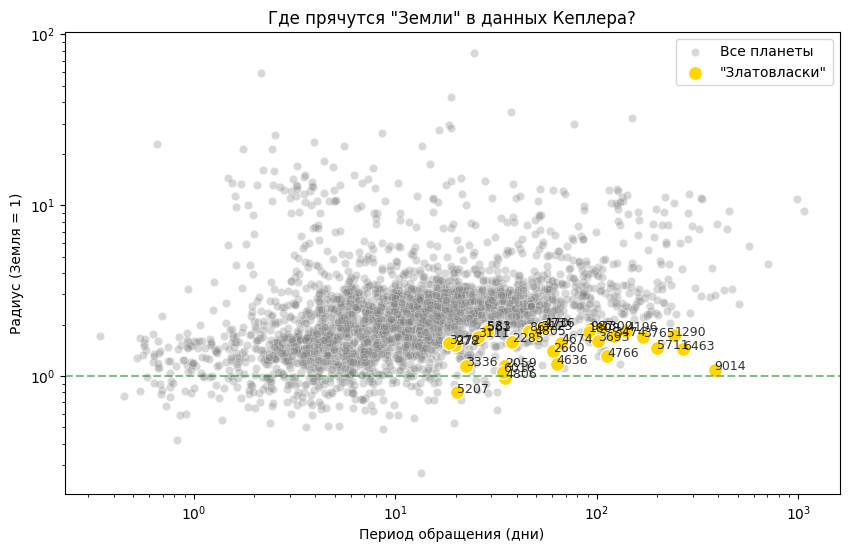

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Earth like planets painted grayРисуем все подтвержденные планеты серым цветом
sns.scatterplot(data=df[df['koi_disposition']=='CONFIRMED'], 
                x='koi_period', y='koi_prad', color='grey', alpha=0.3, label='Все планеты')

# "Goldilock zone"painted gold
sns.scatterplot(data=earth_like, 
                x='koi_period', y='koi_prad', color='gold', s=100, label='"Златовласки"')

plt.xscale('log') # Год бывает от 1 до 1000 дней
plt.yscale('log') # Радиус бывает от 0.1 до 100
plt.axhline(1, color='green', linestyle='--', alpha=0.5) # Линия радиуса Земли
plt.title('Где прячутся "Земли" в данных Кеплера?')
plt.xlabel('Период обращения (дни)')
plt.ylabel('Радиус (Земля = 1)')
plt.legend()

for i, row in earth_like.iterrows():
    plt.text(
        x=row['koi_period'], 
        y=row['koi_prad'], 
        s=str(i),          # Текст подписи — это индекс строки
        fontsize=9,        # Размер шрифта
        color='black',     # Цвет подписи
        alpha=0.8          # Прозрачность, чтобы не перекрывать точку
    )
    
plt.show()